# Step 2: Data preprocessing

From the parsed CWRU bearing data (step 1), we segment the time series of each bearing cycle, followed by computing the spectrograms.

The specs follow:
- https://www.sciencedirect.com/science/article/pii/S0888327021010499
- https://arxiv.org/abs/2407.14625

The resulting data is called the 'preprocessed' data.


In [26]:
# Load the "autoreload" extension so that code can change
%load_ext autoreload
# Always reload modules so that as you change code in src, it gets loaded
%autoreload 2

import os
from copy import deepcopy
import json
import yaml
import re

import numpy as np
import pandas as pd
import scipy
from scipy.signal import ShortTimeFFT
import librosa

import matplotlib.pyplot as plt

from data_preprocessing import (
    create_sequences, compute_fft, compute_stft,
    plot_spectrogram, build_sequence_spectrogram, build_sequence_spectrum,
    convert_window_hop, get_window_fn, window_fn_names)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## FFT (to compute discrete Fourier transform)

In [123]:
fs = 44100.  # sampling frequency

# simulated signal: a 440Hz sine wave followed by a 256Hz sine wave
N0 = int(7. * fs)
t0 = np.arange(N0) / fs
f0 = 440.
x0 = np.sin(2 * np.pi * f0 * t0)

N1 = int(7. * fs)
t1 = np.arange(N0, N0 + N1) / fs
f1 = 256.
x1 = np.sin(2 * np.pi * f1 * t1)

x = np.hstack([x0, x1])

In [124]:
x.shape

(617400,)

In [125]:
N0

308700

In [126]:
fft_freq = np.linspace(0, fs * (N0 - 1) / N0, N0)

In [127]:
fft_freq.shape

(308700,)

In [131]:
fft = scipy.fft.fft(np.vstack([x0, x1]).T, axis=0)

In [132]:
fft.shape

(308700, 2)

(0.0, 1000.0)

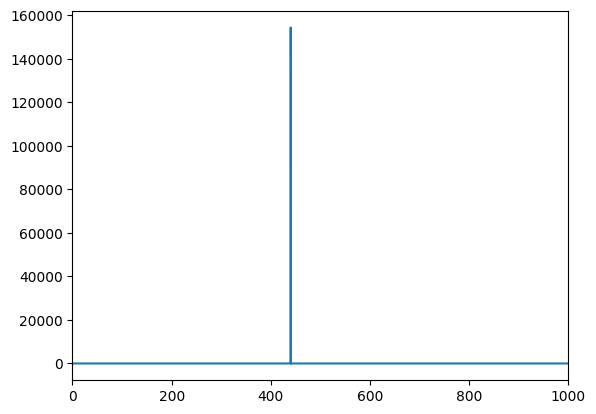

In [134]:
plt.plot(fft_freq, np.abs(fft[:,0]))
plt.xlim(0, 1000)

## Test short-time Fourier transform (STFT) and spectrogram

In [27]:
fs = 44100.  # sampling frequency

# simulated signal: a 440Hz sine wave followed by a 256Hz sine wave
N0 = int(10. * fs)
t0 = np.arange(N0) / fs
f0 = 440.
x0 = np.sin(2 * np.pi * f0 * t0)

N1 = int(10. * fs)
t1 = np.arange(N0, N0 + N1) / fs
f1 = 256.
x1 = np.sin(2 * np.pi * f1 * t1)

x = np.hstack([x0, x1])
x_twoch = np.vstack([x0, x1]).T

In [4]:
x_twoch.shape

(441000, 2)

In [28]:
window_length_sec = 0.025  # frame (=window=sequence) size in seconds
hop = int(0.01 * fs)  #  = stride in the number of timesteps. Here we use 0.01s
mfft = n_fft = int(window_length_sec * fs)  # n_fft = number of data points in each frame (window) = frame size
window_fn = scipy.signal.windows.hamming(int(n_fft / 2))  # window function

In [6]:
# create scipy STFT object
SFT = scipy.signal.ShortTimeFFT(win=window_fn, fs=fs,
                                hop=hop, mfft=mfft)

In [7]:
stft = SFT.stft(x_twoch, axis=0)

In [8]:
stft.shape

(552, 2, 1001)

In [9]:
stft[:,0:1,:].squeeze().shape

(552, 1001)

In [10]:
x_twoch.shape

(441000, 2)

In [12]:
SFT.stft(x0, axis=0).shape

(552, 1001)

In [13]:
stft.shape

(552, 2, 1001)

In [14]:
abs_stft = np.abs(stft)
# The Fourier frequencies are given by a rescaling as follows
# stft_freq = np.arange(0, int(1 + n_fft / 2)) * fs / n_fft
stft_freq = SFT.f
# Time steps
T0 = 0.
stft_time = T0 + np.arange(stft.shape[-1]) * SFT.delta_t

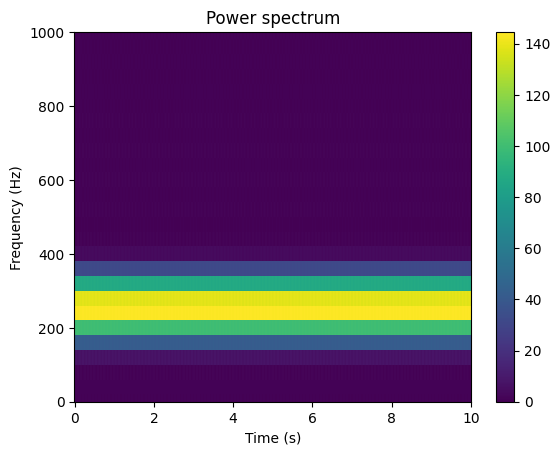

In [90]:
plot_spectrogram(input_data=abs_stft[:,1,:],
                 stft_time=stft_time,
                 stft_freq=stft_freq,
                 input_is_spectrogram=True,
                 ylim=(0, 1000))

In [7]:
stft = SFT.stft(x)

In [8]:
stft.shape

(552, 2003)

In [97]:
# first dimension equals int(1 + n_fft / 2) for a real signal, to be rescaled to the Fourier frequencies
int(1 + n_fft / 2)

552

In [11]:
# second dimension equals number of frames ~ number of strides modulo padding at the ends
len(x) / hop

2000.0

In [16]:
len(x) / fs

20.0

In [17]:
np.hstack([t0, t1])

array([0.00000000e+00, 2.26757370e-05, 4.53514739e-05, ...,
       1.99999320e+01, 1.99999546e+01, 1.99999773e+01])

In [22]:
(np.arange(stft.shape[1]) * hop) / fs

array([0.000e+00, 1.000e-02, 2.000e-02, ..., 2.000e+01, 2.001e+01,
       2.002e+01])

In [37]:
abs_stft = np.abs(stft)
# The Fourier frequencies are given by a rescaling as follows
# stft_freq = np.arange(0, int(1 + n_fft / 2)) * fs / n_fft
stft_freq = SFT.f
# Time steps
T0 = 0.
stft_time = T0 + np.arange(stft.shape[1]) * SFT.delta_t

In [ ]:
def convert_window_hop(window_length_sec: float,
                       hop_sec: float,
                       fs: float):
    mfft = n_fft = int(window_length_sec * fs)  # n_fft = number of data points in each frame (window) = frame size
    hop = int(hop_sec * fs)  #  = stride in the number of timesteps. Here we use 0.01s
    return mfft, hop

In [158]:
def compute_stft(x: np.ndarray,
                 fs: float,
                 mfft: int, hop: int,
                 window_fn=None,
                 return_spectrogram: bool = True,
                 start_time: float = 0.,
                 ):
    '''Computes short-time Fourier transform (STFT) of a given possible
    multivariate signal, using scipy.

    Args:
        x (np.ndarray): a univariate/multivariate signal.
            If multivariate, x.shape == (signal_length, num_channels)
        fs (float): sampling frequency in Hz
        mfft (int): = n_fft = frame size
            = number of data points in each frame (window)
        hop (int): hop = stride in the number of timesteps
        window_fn: a scipy window function.
            Defaults to None, in which case we use
            scipy.signal.windows.hann(mfft)
        return_spectrogram (bool, optional):
            return spectrogram, otherwise return stft.
            Defaults to True.
        start_time (float, optional): start time of the signal.
            Defaults to 0.

    Returns:
        stft_freq (np.ndarray): Fourier frequencies of the STFT
        stft_time (np.ndarray): time steps of the STFT
        spectrogram (np.ndarray) if return_spectrogram,
        else stft (np.ndarray)
        SFT: scipy.signal.ShortTimeFFT object, for possible later use
            e.g. computing cepstrum
    '''
    x_ = x
    if x.ndim == 1:
        x_ = np.expand_dims(x, axis=-1)
    if not window_fn:
        window_fn = scipy.signal.windows.hann(mfft)  # window function
    # create scipy STFT object
    SFT = scipy.signal.ShortTimeFFT(win=window_fn, fs=fs,
                                    hop=hop, mfft=mfft)
    # compute stft of the given signal
    stft = SFT.stft(x_, axis=0)
    # The Fourier frequencies are given by a rescaling as follows
    # stft_freq = np.arange(0, int(1 + n_fft / 2)) * fs / n_fft
    stft_freq = SFT.f
    # time steps
    stft_time = start_time + np.arange(stft.shape[-1]) * SFT.delta_t
    if return_spectrogram:
        spectrogram = np.square(np.abs(stft))
        return stft_freq, stft_time, spectrogram, SFT
    else:
        return stft_freq, stft_time, stft, SFT

In [159]:

def plot_spectrogram(input_data: np.ndarray,
                     stft_freq: np.ndarray,
                     stft_time: np.ndarray,
                     input_is_spectrogram: bool = True,
                     plot_channel: int = 0,
                     ylim: tuple = None
                     ):
    '''Plots spectrogram

    Args:
        input_data (np.ndarray): either spectrogram or stft.
            User needs to set input_is_spectrogram accordingly
        stft_freq (np.ndarray): Fourier frequencies of the STFT
        stft_time (np.ndarray): time steps of the STFT
        input_is_spectrogram (bool, optional): Defaults to True.
        ylim (tuple, optional): Defaults to None.
    '''
    input_data_ = input_data
    if not input_is_spectrogram:
        input_data_ = np.square(np.abs(input_data_))
    if input_data_.ndim == 2:
        input_data_ = np.expand_dims(input_data_, axis=1)
    plt.pcolormesh(stft_time, stft_freq, input_data_[:, plot_channel, :])
    if ylim:
        plt.ylim(ylim)
    plt.title('Power spectrum')
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (s)')
    plt.colorbar()
    plt.show()

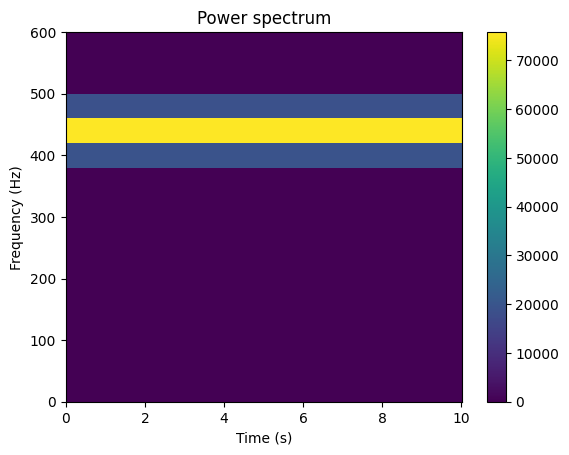

In [160]:
plot_spectrogram(input_data=stft,
                 stft_time=stft_time,
                 stft_freq=stft_freq,
                 input_is_spectrogram=False,
                 ylim=(0, 600))

Compare against librosa's STFT

In [30]:
librosa.stft(x0, n_fft=n_fft, hop_length=hop,
             window=scipy.signal.windows.hann(n_fft)).shape

(552, 1001)

In [39]:
stft2 = librosa.stft(x, n_fft=n_fft, hop_length=hop)

In [40]:
stft2.shape

(552, 2001)

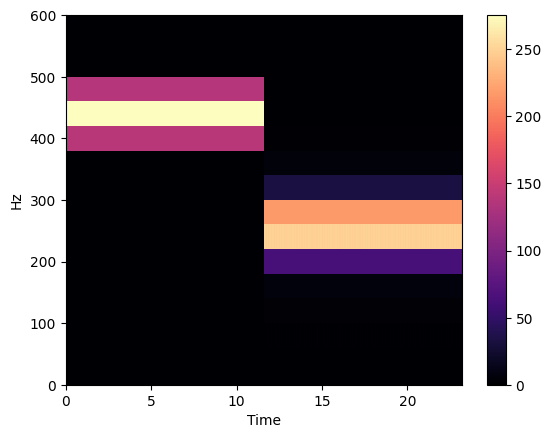

In [45]:
librosa.display.specshow(np.abs(stft2), sr=fs, y_axis='hz', x_axis='time')
plt.ylim(0,600)
plt.colorbar()

## Cepstrum

In [54]:
x

array([ 0.        ,  0.06264832,  0.12505052, ..., -0.10920324,
       -0.07288296, -0.03646573])

In [57]:
cepstrum = np.square(SFT.istft(
    np.log10(np.square(abs_stft)),
    k0=0, k1=x.shape[0]))

In [59]:
cepstrum.shape

(882000,)

(10.0, 11.0)

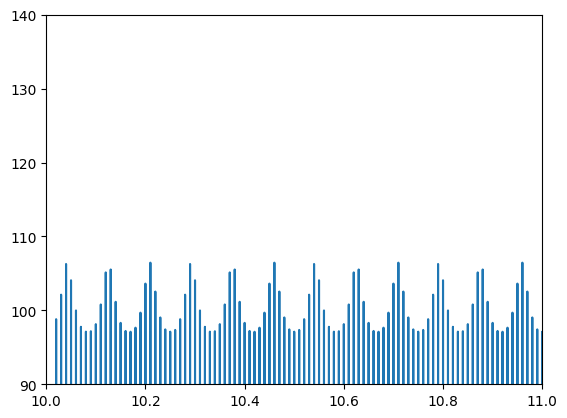

In [68]:
plt.plot(np.hstack([t0, t1]), cepstrum)
plt.ylim(90, 140)
plt.xlim(10, 11)

## Sequence construction

In [5]:
fs = 44100.  # sampling frequency

# simulated signal: a 440Hz sine wave followed by a 256Hz sine wave
N2 = int(10. * fs)
t2 = np.arange(N2) / fs
f20 = 440.
x20 = np.sin(2 * np.pi * f20 * t2)

f21 = 256.
x21 = np.sin(2 * np.pi * f21 * t2)

x2 = np.vstack([x20, x21]).T

In [6]:
x2.shape

(441000, 2)

In [7]:
sequence_length = 100000 # length of sequence in number of data points
sequence_stride = int(0.1 * sequence_length)


In [8]:
sequences = create_sequences(x2,
                             sequence_length=sequence_length,
                             stride=sequence_stride)

In [9]:
sequences.shape

(36, 100000, 2)

### FFT for each sequence

In [17]:
seq_fft = []
fft_freq = None
for n in range(sequences.shape[0]):
    x_ = sequences[n, ...]
    fft_freq_, fft_ = compute_fft(x_, fs=fs, return_spectrum=True)
    seq_fft.append(fft_)
fft_freq = fft_freq_

In [18]:
seq_fft[0].shape

(100000, 2)

(0.0, 1000.0)

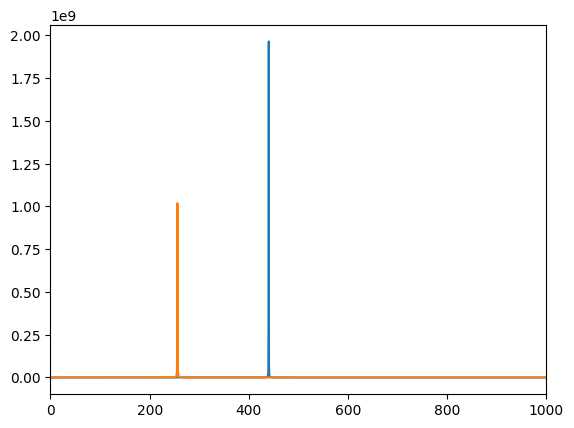

In [19]:
plt.plot(fft_freq, seq_fft[0])
plt.xlim(0, 1000)

### Spectrogram for each sequence

In [20]:
window_length_sec = 0.025  # frame (=window=sequence) size in seconds
hop = int(0.01 * fs)  #  = stride in the number of timesteps. Here we use 0.01s
mfft = n_fft = int(window_length_sec * fs)  # n_fft = number of data points in each frame (window) = frame size
window_fn = scipy.signal.windows.hann(n_fft)  # window function


In [32]:
seq_spectrogram = []
stft_freq = None
stft_time = None
for n in range(sequences.shape[0]):
    x_ = sequences[n, ...]
    stft_freq_, stft_time_, spectrogram, SFT = \
        compute_stft(x_,
                     fs=fs, mfft=mfft, hop=hop,
                     window_fn=window_fn,
                     return_spectrogram=True)
    seq_spectrogram.append(spectrogram)
stft_freq = stft_freq_
stft_time = stft_time_

In [39]:
len(seq_spectrogram)

36

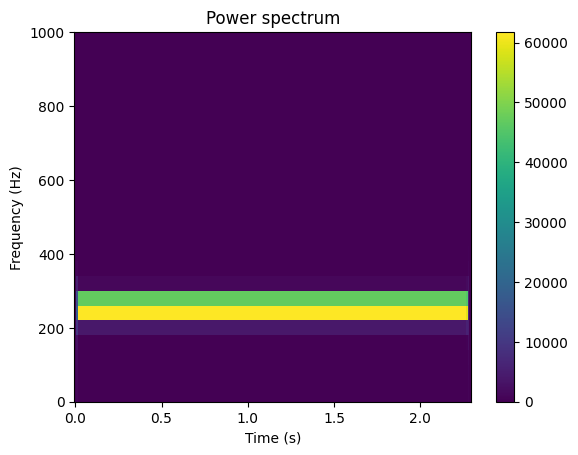

In [41]:
plot_spectrogram(seq_spectrogram[30],
                 stft_freq=stft_freq,
                 stft_time=stft_time,
                 plot_channel=1,
                 ylim=(0,1000))

## Bearing example

In [49]:
with open('data_parsed/parsed_metadata.json', 'r') as f:
    metadata = json.load(f)

In [51]:
parsed_data_paths = [m['parsed_data_path'] for m in metadata]

In [54]:
cycle_ = metadata[-20]
cycle_

{'raw_data_path': './data/48k_Drive_End_Bearing_Fault_Data/OR/007/@6/137_2.mat',
 'cycle_id': '137',
 'fault_label': 'DE_OR',
 'motor_load_hp': '2',
 'sampling_freq_khz': 48.0,
 'fault_type': 'DE',
 'fault_location': 'OR',
 'fault_diameter': '007',
 'OR_position': '@6',
 'rpm': 1750,
 'df_length': 486804,
 'df_columns': ['DE_time', 'FE_time', 'cycle_id'],
 'parsed_data_path': './data_parsed/137.csv'}

In [33]:
df0 = pd.read_csv(cycle_['parsed_data_path']).set_index('index').sort_index()

In [34]:
df0

,DE_time,FE_time,BA_time,cycle_id
index,,,,
0,-0.072121,0.077456,0.073272,119
1,0.303104,0.045611,0.069329,119
2,0.033137,-0.011095,0.054803,119
3,-0.207267,0.092865,0.064098,119
4,0.096974,0.017258,0.033880,119
...,...,...,...,...
121405,-0.050680,0.022189,0.029011,119
121406,0.158049,-0.088140,0.003742,119
121407,0.088202,-0.012738,0.057539,119


In [35]:
x0 = df0[['DE_time', 'FE_time']].to_numpy()

In [57]:
yaml.load('''
# sampling frequency fs is given by sampling_freq_khz * 1000
sequence_length: 11500 # length of sequence in number of data points
sequence_stride: 345 # stride of sequence in number of data points
# spectrogram specs
hop: 54  #  = stride in the number of timesteps. Here we use 0.01s
mfft: 452  # n_fft = number of data points in each frame = frame size
# window function
window_fn_name: "hann"
window_fn_args:
M: 104
channel_first: True  # otherwise channel is on axis=1 from scipy. For PyTorch use
          ''', yaml.SafeLoader)

{'sequence_length': 11500,
 'sequence_stride': 345,
 'hop': 54,
 'mfft': 452,
 'window_fn_name': 'hann',
 'window_fn_args': None,
 'M': 104,
 'channel_first': True}

In [36]:
fs = cycle_['sampling_freq_khz'] * 1000

In [43]:
sequence_length = 11500 # length of sequence in number of data points
sequence_stride = int(0.03 * sequence_length)
hop = 54  #  = stride in the number of timesteps. Here we use 0.01s
mfft = n_fft = 452  # n_fft = number of data points in each frame (window) = frame size
window_fn_name = 'hann'
window_fn_args = {'M': 104}

In [44]:
stft_freq, stft_time, seq_spectrogram = build_sequence_spectrogram(
    x=x0,
    sequence_length=sequence_length, sequence_stride=sequence_stride,
    fs=fs, mfft=mfft, hop=hop,
    window_fn_name=window_fn_name, window_fn_args=window_fn_args
)

In [45]:
seq_spectrogram[0].shape

(2, 227, 214)

In [66]:
np.savez('test.npz', stft_freq=stft_freq, stft_time=stft_time, seq_spectrogram=seq_spectrogram)

In [67]:
npzfiles = np.load('test.npz')

In [69]:
npzfiles.values()

ValuesView(<numpy.lib.npyio.NpzFile object at 0x7f8004313e20>)


In [71]:
stft_freq = npzfiles['stft_freq']
stft_time = npzfiles['stft_time']
seq_spectrogram = npzfiles['seq_spectrogram']

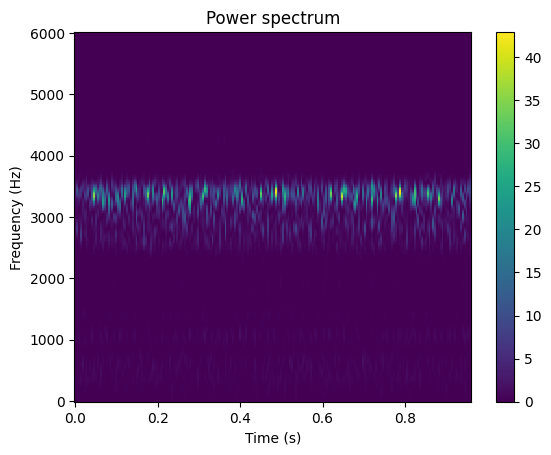

In [73]:
plot_spectrogram(seq_spectrogram[0].swapaxes(0,1),
                 stft_freq=stft_freq,
                 stft_time=stft_time,
                 plot_channel=0,
                #  ylim=(0,1000)
                 )